In [31]:
import os
os.environ["OMP_NUM_THREADS"] = "3"

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.metrics import confusion_matrix

from sklearn.decomposition import PCA

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

sns.set_style("whitegrid")

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [2]:
df = pd.read_csv("patient_segments2.csv")

print("Dataset Loaded Successfully")

print("Shape :", df.shape)

df.head()

Dataset Loaded Successfully
Shape : (569, 32)


,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Cluster
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   diagnosis                569 non-null    int64  
 1   radius_mean              569 non-null    float64
 2   texture_mean             569 non-null    float64
 3   perimeter_mean           569 non-null    float64
 4   area_mean                569 non-null    float64
 5   smoothness_mean          569 non-null    float64
 6   compactness_mean         569 non-null    float64
 7   concavity_mean           569 non-null    float64
 8   concave points_mean      569 non-null    float64
 9   symmetry_mean            569 non-null    float64
 10  fractal_dimension_mean   569 non-null    float64
 11  radius_se                569 non-null    float64
 12  texture_se               569 non-null    float64
 13  perimeter_se             569 non-null    float64
 14  area_se                  5

In [4]:
df.describe()


,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Cluster
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,0.372583,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.669596
std,0.483918,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.470773
min,0.000000,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,0.000000,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,0.000000,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,1.000000,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,1.000000,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


In [5]:
print(df.isnull().sum())

diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
Cluster                    0
dtype: int64


In [6]:
print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 0


In [7]:
df = df.drop_duplicates()

print("New Shape :", df.shape)

New Shape : (569, 32)


In [8]:
if 'diagnosis' in df.columns:

    le = LabelEncoder()

    df['diagnosis'] = le.fit_transform(df['diagnosis'])

    print("Label Encoding Completed")

df.head()

Label Encoding Completed


,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Cluster
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


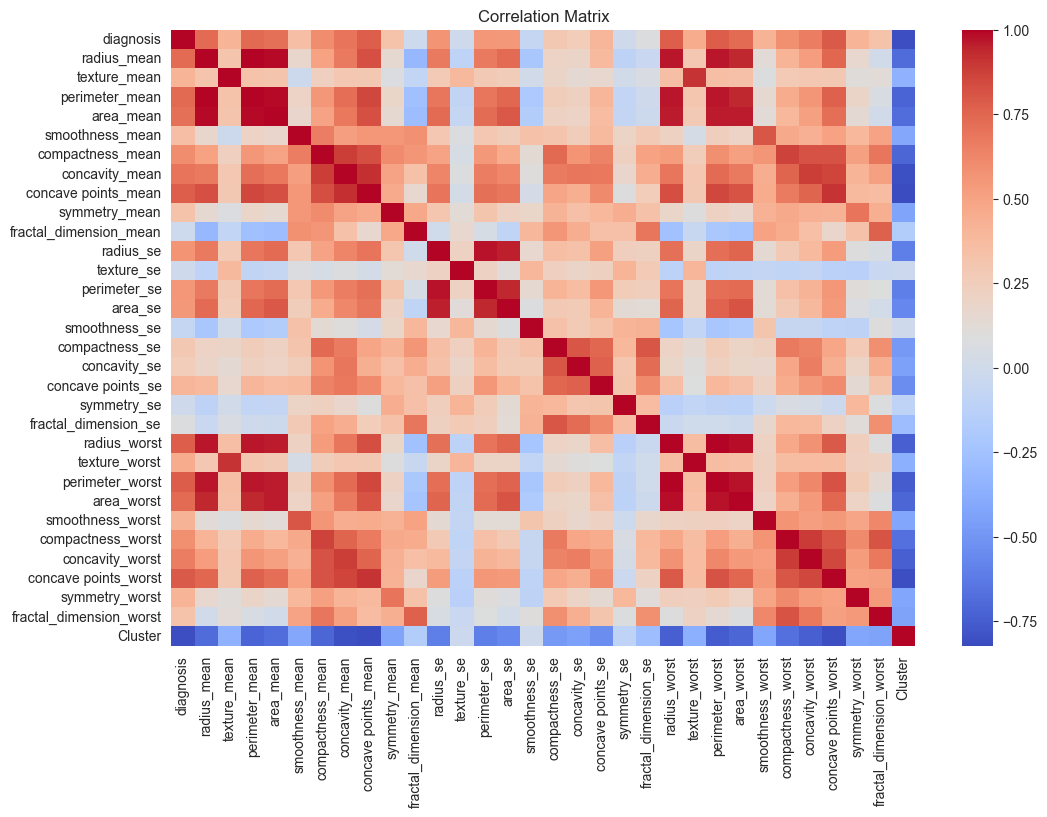

In [9]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(),
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

In [10]:
selected_features = [

    'radius_mean',
    'texture_mean',
    'perimeter_mean',
    'area_mean',
    'smoothness_mean',
    'compactness_mean',
    'concavity_mean',
    'concave points_mean',
    'symmetry_mean'

]

X = df[selected_features]

y = df['diagnosis']

print("Features Shape :", X.shape)
print("Target Shape :", y.shape)

Features Shape : (569, 9)
Target Shape : (569,)


In [11]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Scaling Completed")

Scaling Completed


In [12]:
wcss = []

for k in range(1,11):

    model = KMeans(
        n_clusters=k,
        init='k-means++',
        random_state=42,
        n_init=10
    )

    model.fit(X_scaled)

    wcss.append(model.inertia_)

print("WCSS Calculated")

WCSS Calculated


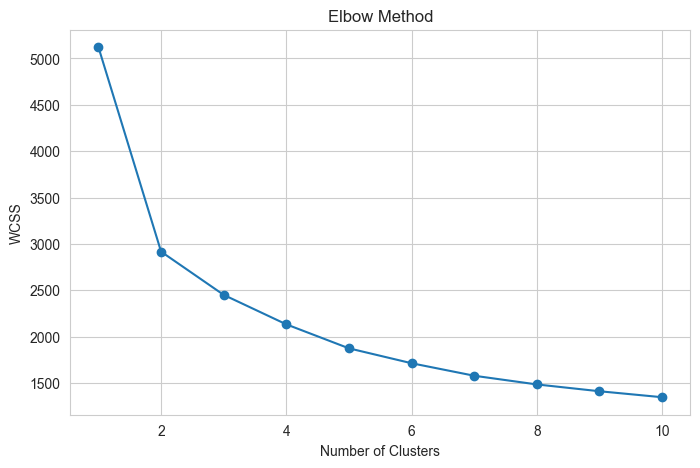

In [13]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    wcss,
    marker='o'
)

plt.title("Elbow Method")

plt.xlabel("Number of Clusters")

plt.ylabel("WCSS")

plt.show()

In [14]:
kmeans = KMeans(
    n_clusters=2,
    init='k-means++',
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

df["Cluster"] = clusters

print("Clustering Completed")

Clustering Completed


In [15]:
score = silhouette_score(
    X_scaled,
    clusters
)

print("Silhouette Score :", round(score,4))

Silhouette Score : 0.4164


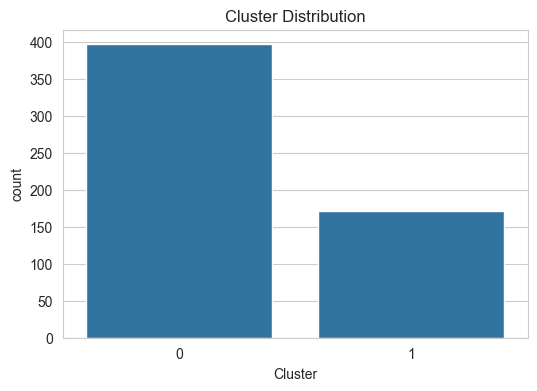

In [16]:
plt.figure(figsize=(6,4))

sns.countplot(
    x=df["Cluster"]
)

plt.title("Cluster Distribution")

plt.show()

In [17]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(
    X_pca,
    columns=['PCA1','PCA2']
)

pca_df["Cluster"] = clusters

pca_df.head()

,PCA1,PCA2,Cluster
0,5.020811,2.765995,1
1,1.847320,-2.240095,1
2,4.012625,-0.070391,1
3,3.142418,5.151176,1
4,3.223664,-0.938076,1


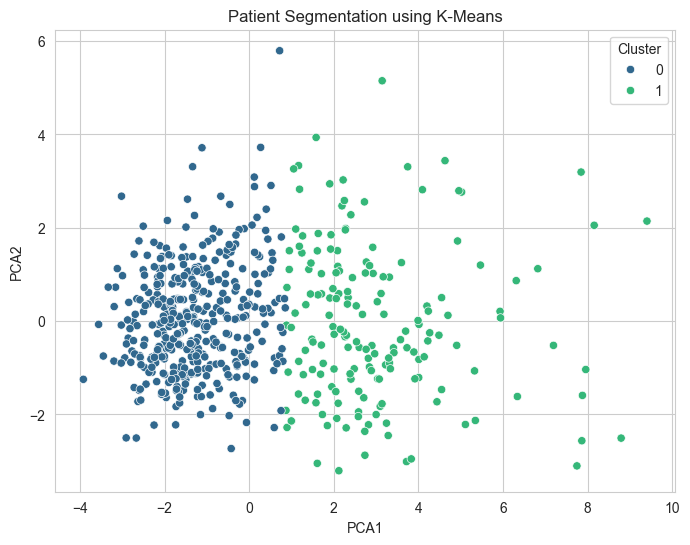

In [18]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=pca_df,
    x="PCA1",
    y="PCA2",
    hue="Cluster",
    palette="viridis"
)

plt.title("Patient Segmentation using K-Means")

plt.show()

In [19]:
cluster_summary = df.groupby("Cluster")[selected_features].mean()

cluster_summary

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean
Cluster,,,,,,,,,
0,12.400524,18.338690,79.764282,484.315365,0.092661,0.080604,0.047993,0.027679,0.174097
1,18.112913,21.484593,120.139302,1048.597093,0.104900,0.159129,0.182986,0.097945,0.197469


In [29]:
print("Cluster 0 = Low Risk Patients")

print("Cluster 1 = High Risk Patients")

Cluster 0 = Low Risk Patients
Cluster 1 = High Risk Patients


In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

print("Train Shape :", X_train.shape)
print("Test Shape :", X_test.shape)

Train Shape : (455, 9)
Test Shape : (114, 9)


In [21]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(
    X_train,
    y_train
)

print("Model Trained Successfully")

Model Trained Successfully


In [22]:
pred = rf.predict(X_test)

In [23]:
accuracy = accuracy_score(
    y_test,
    pred
)

print(
    "Accuracy :",
    round(accuracy*100,2),
    "%"
)

Accuracy : 94.74 %


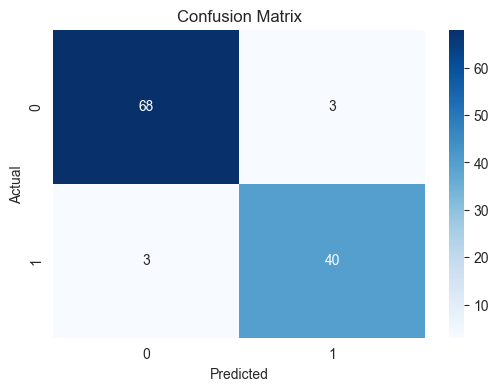

In [32]:
cm = confusion_matrix(
    y_test,
    pred
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [24]:
print(
    classification_report(
        y_test,
        pred
    )
)

              precision    recall  f1-score   support

           0       0.96      0.96      0.96        71
           1       0.93      0.93      0.93        43

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



In [25]:
importance = pd.DataFrame({

    "Feature": selected_features,

    "Importance": rf.feature_importances_

})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
7,concave points_mean,0.335418
2,perimeter_mean,0.160158
3,area_mean,0.145720
6,concavity_mean,0.140825
0,radius_mean,0.072374
1,texture_mean,0.067660
4,smoothness_mean,0.030118
5,compactness_mean,0.029137
8,symmetry_mean,0.018590


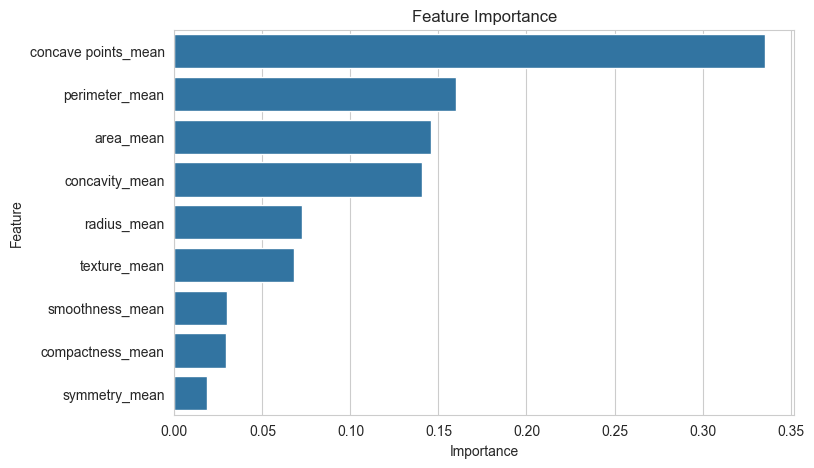

In [26]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance")

plt.show()

In [27]:
df.to_csv(
    "segmented_patients.csv",
    index=False
)

print("File Saved Successfully")

File Saved Successfully


In [28]:
print("="*50)
print("PATIENT SEGMENTATION SYSTEM")
print("="*50)

print("Total Patients :", len(df))

print(
    "Clusters Created :",
    df["Cluster"].nunique()
)

print(
    "Silhouette Score :",
    round(score,4)
)

print(
    "Random Forest Accuracy :",
    round(accuracy*100,2),
    "%"
)

print("\nProject Completed Successfully")

PATIENT SEGMENTATION SYSTEM
Total Patients : 569
Clusters Created : 2
Silhouette Score : 0.4164
Random Forest Accuracy : 94.74 %

Project Completed Successfully
